<a id="exercise"></a>

## Week 3 考卷：光線與紀錄
> 作品可現場操作或用手機展示，完成後回答題末問題。可查資料或使用 AI。

### 作品：在電腦顯示光線讀值
用課堂 ESP32-S3 開發板與光敏模組，讓電腦持續顯示光線讀值。

**特色：**在 Arduino IDE 的 Serial Monitor（序列監控視窗）觀察光線變化。開發板上的 ESP32 晶片把光敏訊號電壓轉成整數，這個數字叫原始讀值 **raw**；本題顯示範圍為 0～4095。

> 改線前拔 USB 與其他電源；先確認接線與供電相容，不將 5 V 接入 ESP32 訊號腳。不確定接法時保持斷電，不通電試錯。

**預期結果：**Serial Monitor 持續出現 0～4095 的整數，可讀到沒遮光與遮光時的數值；變化方向與數字以本組實測為準。

**驗證方法：**固定感測器、燈與接線的位置，觀察「沒遮光」與「用不透光紙遮住」時的數字，各記連續三筆 raw。

### Q1．你的作品在兩種光線下各讀到多少？

| 當時的情況 | 第 1 筆 raw | 第 2 筆 raw | 第 3 筆 raw |
|---|---|---|---|
| 沒遮光 | ______ | ______ | ______ |
| 遮光 | ______ | ______ | ______ |

### Q2．raw=800 可以寫成 0.8 V 嗎？
請說明原始讀值 800 代表什麼，以及你的判斷理由。

__________________________

__________________________


<a id="exercisemeter"></a>

## Q3．電表會量到多少電壓？
> 紙上題：在圖上作答，不用重新接線。

開發板的 3V3 電源腳提供 3.3 V，GND 接地腳作為 0 V。兩腳之間串接兩顆電阻：靠近 3V3 腳的是 1 kΩ，靠近 GND 腳的是 10 kΩ；1 kΩ = 1000 Ω。

**要量的位置：兩顆電阻連接處與 GND 之間。**圓點是導線接點，兩個小長方形是電阻；採標示阻值計算，忽略電表的影響。

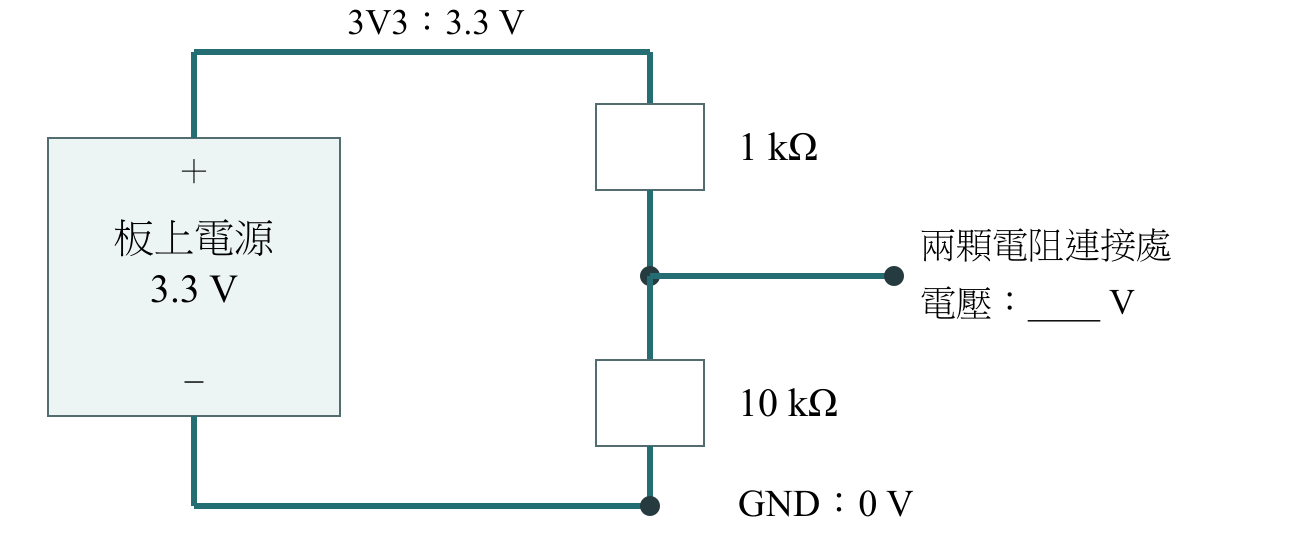

**1. 畫電流：**在導線與電源內加箭頭，標出傳統電流繞完整回路的方向。

**2. 算電壓：**兩顆電阻連接處比 GND 高多少 V？寫出計算式，填入圖中空格。

__________________________

__________________________


**3. 設定電表：**用 A830L 萬用電表量上述兩點，讓電表顯示正值。表筆一端的插頭插入電表，另一端的金屬筆尖碰測量位置。

| 問題 | 你的答案 |
|---|---|
| 黑色表筆的插頭插入電表哪個孔？ | __________________________ |
| 紅色表筆的插頭插入電表哪個孔？ | __________________________ |
| 電表旋鈕選哪種量測、哪個範圍？ | __________________________ |
| 黑色筆尖碰圖中的哪裡？ | __________________________ |
| 紅色筆尖碰圖中的哪裡？ | __________________________ |


<a id="worksheetsafety"></a>

## Q4．這樣接表筆，能量電壓嗎？
> 只在紙上回答，不把錯誤接法接到實物。

同學想用 **A830L 萬用電表**，量 ESP32 開發板的 3V3 電源腳與 GND 接地腳之間的電壓。目前開發板尚未接上電源。

### 先分清楚：插頭插電表，筆尖碰電路
這支電表下方有三個表筆插孔，旁邊分別印著 **10A、COM、VΩmA**。其中 10A 是電流量測插孔的標字，A 是電流單位「安培」；不是麵包板孔號，也不是本次量到的電流。

### 同學目前的接法
| 檢查哪個部分 | 同學的設定或打算碰的位置 |
|---|---|
| 黑色表筆的插頭 | 插入萬用電表上標示 COM 的插孔 |
| 紅色表筆的插頭 | 插入萬用電表上標示 10A 的插孔 |
| 萬用電表的旋鈕 | 選擇直流電壓的 20 V 量測範圍 |
| 黑色表筆的金屬筆尖 | 準備碰開發板的 GND 接地腳 |
| 紅色表筆的金屬筆尖 | 準備碰開發板的 3V3 電源腳 |

同學認為旋鈕已選「量電壓」，就可以接上開發板的 USB 電源開始量測。

**為什麼仍應阻止他供電？**指出接法中的問題，畫出或寫出供電後可能形成的電流路徑，解釋危險的原因。

__________________________

__________________________


<a id="worksheetflow"></a>

## 從光線到紀錄，中間經過什麼？
ESP32-S3 開發板連著光敏模組和一顆按鈕。模組的電源端、接地端分別接開發板的 3V3、GND 腳；模組上標示 S 的訊號腳接開發板的 GPIO4 腳。按鈕兩端接開發板的 GPIO5、GND 腳，GPIO5 使用晶片內的上拉電阻讀取按鈕。

每次新的按下，程式讀取一次 GPIO4，在 Serial Monitor（Arduino 的文字視窗）顯示第幾筆、raw，以及程式自動記下的「讀到這筆時，距離開機多久」。按住不放不重複記錄，放開再按才增加下一筆。

USB 線插在開發板背面標示 COM 的 USB 接頭，另一端接電腦。此處 COM 是開發板接頭的標字，不是電表插孔；開發板上的 CH343 晶片把 ESP32 經 UART 串列通訊送出的資料轉成 USB 資料。

### Q5-1．畫出資訊流
依上述條件，從光線改變開始，畫到電腦出現一筆資料。另畫按鈕的資訊在哪裡加入。標出接腳、電壓轉成 raw 的位置及資料到電腦的路徑；每支箭頭註明傳遞什麼。


__________________________

__________________________


### Q5-2．只斷開 S 訊號線
在紙上把「光敏模組 S 訊號腳到開發板 GPIO4 腳」的導線畫斷，其他供電、接線與程式不變。Serial Monitor 仍出現數字，能否當成光線資料？能否保證變成 0？請解釋原因。


__________________________

__________________________


<a id="projectintro"></a>

## 把光線讀值做成可以使用的作品
Q1 已讓電腦顯示光線數字。接下來加入按鈕或 OLED 小螢幕，讓使用者能決定何時記錄，或直接看到光線的變化。

### 先做 A：按一下，自動記錄三次
按鈕只按一次，作品就自動量三次光線，並把三筆結果顯示在電腦。這是同一段短時間內的三次量測。

### 再看三個延伸作品 B、C、D
- **B．可以暫停的遮光計數器：**用按鈕啟動或暫停，計算感測器被遮住幾次。
- **C．桌面光線觀測器：**不用按按鈕，在 OLED 看目前讀值，以及這次開機後的最小、最大值。
- **D．按一下，留下光線快照：**OLED 持續顯示目前值；按一下，另外保留當時的值，方便比較前後變化。

各題是分開展示的作品，不必把所有功能塞進同一支程式。可以沿用已有的零件與程式，但每次展示都要符合該題的行為。

### 每題怎樣算完成？
先看「作品」與「預期結果」，完成後依「驗證方法」操作。現場或用手機展示畫面與反應，最後回答題末問題，說明自己的程式如何完成要求。

預期畫面中的光敏數字只是示例；作品顯示的是自己的實際量測，不要求做出相同數字。


<a id="buildexercise"></a>

## A．按一次，自動取三筆
**作品：**用光敏模組與一顆按鈕做光線取樣器。「取一筆」就是重新量一次當下光線，記下讀值。按一下後，程式自動取三筆並顯示在電腦，不必連按三下。

**特色：**辨識到新的按下就取第一筆；至少隔 0.2 秒取第二筆，再至少隔 0.2 秒取第三筆，之後停止。計時由程式完成，不靠人抓時間。

> 改線前拔除 USB 與其他電源，換程式前先拆外接線。確認接線、供電及腳位用途後再接回；不要把電源腳或設定為高電壓輸出的 GPIO 接腳 直接接 GND。

### 預期結果：按一下，電腦新增三行
以下是假設第一次按下的畫面。時間從開機起算，單位是毫秒；1000 毫秒 = 1 秒。光敏數值與時間都是示例。

| 第幾次開始 | 這次第幾筆 | 光敏 raw | 讀取時間（毫秒） |
|---|---|---|---|
| 1 | 1 | 420 | 5000 |
| 1 | 2 | 425 | 5200 |
| 1 | 3 | 418 | 5400 |

同一次開始的三筆分別來自三次量測，不是把第一筆複製三次。光線沒變時，三筆數字也可能相同，不能只用數字不同來判斷是否重新量測。

### 三筆讀完前後，按鈕應該怎麼反應？
- 按住不放或提早放開，都只完成這次三筆，之後停止。
- 尚未讀完又按一下，顯示「仍在讀取，這次按下不接受」；原三筆照常完成，不在之後補做。
- 三筆完成後放開再按，開始第二次，新增第 1～3 筆；畫面能區分兩次。
- 按開發板的 RST 重新啟動按鈕會中止讀取；先放開再按，重新從第一次開始。


<a id="batchrecord"></a>

## A．怎樣確認作品完成？
**驗證方法：**先展示正式的 0.2 秒間隔，再暫時放慢，檢查讀取途中按鈕仍能回應。時間由程式顯示，不用手動計時或抄時間。

### 1. 正式間隔：一次三筆，兩次共六筆
先放開按鈕、按開發板的 RST 按鈕，再按住按鈕兩秒。畫面只新增三筆。放開後再按一次，才新增下一次的三筆；每次第二、三筆與前一筆的時間差都至少是 200 毫秒（0.2 秒）。

### 2. 暫時放慢：讓手動操作來得及
把作品暫改為兩筆相隔約一秒，筆數仍是三筆。以下每列分開測試；開始前先放開按鈕，再按開發板的 RST 按鈕。

| 操作 | 作品應有的結果 |
|---|---|
| 按一下並放開；第一筆出現後遮住感測器 | 仍完成三筆；後兩筆反映遮住後的光線 |
| 按下；第一筆出現後放開約半秒，再按住 | 顯示仍在讀取的提示；原三筆完成後停止，不補做 |
| 按下；第一筆出現後按開發板的 RST 按鈕 | 這次讀取中止；放開再按，重新從第一次開始 |

測完恢復 0.2 秒，再確認一次三筆。慢速測試用來看操作反應，不用它證明正式間隔正確；換程式依前頁安全提醒操作。

### A．你的程式如何完成三次取樣？
從自己的程式指出「重新量測光線」的敘述，說明第一筆與後兩筆各在什麼時候執行、何時停止。用關鍵程式片段加文字說明，如何避免複製第一筆。

__________________________

__________________________


<a id="projectbutton"></a>

## B．可以暫停的遮光計數器
**作品：**用光敏模組與一顆按鈕做遮光計數器。每次由未遮住變成遮住，計數一次；Serial Monitor 顯示啟動／暫停狀態與次數。

<figure><svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 650 222" role="img" aria-label="Serial Monitor 預期內容示意"><text x="16" y="24" font-size="19">按鈕啟動後，遮住一次</text><text x="348" y="24" font-size="19">暫停後再遮住，不增加</text><rect x="8" y="40" width="302" height="165" rx="4" fill="#f1f4f5" stroke="#477b80"/><rect x="340" y="40" width="302" height="165" rx="4" fill="#f1f4f5" stroke="#477b80"/><text x="24" y="73" font-size="20" font-family="Consolas,monospace" fill="#263b40">mode=RUNNING</text><text x="24" y="105" font-size="20" font-family="Consolas,monospace" fill="#263b40">count=1</text><text x="356" y="73" font-size="20" font-family="Consolas,monospace" fill="#263b40">mode=PAUSED</text><text x="356" y="105" font-size="20" font-family="Consolas,monospace" fill="#263b40">count=1</text></svg><figcaption>Serial Monitor 預期內容示意；不是實測截圖，文字位置與字型可自行設計。</figcaption></figure>

| 使用者看到的資訊 | 意義 |
|---|---|
| mode=RUNNING／mode=PAUSED | 畫面上的 mode 欄顯示正在計數／暫停計數 |
| count | 畫面上的次數欄：這次開機後，計數期間完成的遮光次數 |
| 一次遮光 | 從未遮住變成遮住；持續遮住不算新的一次 |

**特色：**按一下按鈕切換啟動／暫停；按住不放只切換一次。暫停保留次數，但暫停期間的動作不補算。按開發板的 RST 按鈕 後回到 PAUSED、count=0，不要求斷電保存。

**判斷依據：**接線與位置相同時，可沿用 Q1 的未遮光／遮光資料；兩種情況必須能區分。條件改變才重新量測，不直接套用別組的分界。

> 改線前拔除 USB；供電、訊號電壓與 GPIO 仍須符合已確認的器材規格。不要把電源腳或設定為高電壓輸出的 GPIO 接腳 直接接 GND。


<a id="projectbuttonresults"></a>

## B．怎樣確認作品完成？
**驗證方法：**從未遮住、按鈕放開的狀態按開發板的 RST 按鈕，依序做下表操作，展示狀態與次數。

遮住或移開至少一秒，避開分界附近的光線。除第 8 步外，按鈕按一下就放開。

| 順序與操作 | 畫面應顯示的狀態與遮光次數 |
|---|---|
| 1. 啟動後不操作 | PAUSED／0 |
| 2. 按一下按鈕 | RUNNING／0 |
| 3. 遮住並保持三秒 | RUNNING／1，不持續增加 |
| 4. 移開，再遮住 | RUNNING／2 |
| 5. 保持遮住，按一下暫停 | PAUSED／2 |
| 6. 暫停時移開、遮住兩次 | PAUSED／2 |
| 7. 遮住時恢復，再移開、遮住 | RUNNING／2 → RUNNING／3 |
| 8. 仍在 RUNNING，按住按鈕兩秒 | 只切換成 PAUSED／3，不反覆切換 |
| 9. 放開按鈕，再按開發板的 RST 按鈕 | PAUSED／0 |

模式或次數改變時，Monitor 留下紀錄。開機已遮住不加次數；按鈕按住開機，放開再按才接受。模式切換不算遮光，暫停中的動作不補算。

### B．你的程式如何判斷現在被遮住？
寫出自己的判斷規則，包含比較方向與分界數字，並引用本組實測作為依據；條件相同可用 Q1。可用程式或文字回答。

__________________________

__________________________


<a id="projectoled"></a>

## C．桌面光線觀測器
**作品：**用光敏模組與 OLED 做光線觀測器。不用按按鈕，就能看到目前讀值，以及這次開機後量到的最大、最小值。

<figure><svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 650 222" role="img" aria-label="OLED 預期畫面示意"><text x="16" y="24" font-size="19">剛開始，第一筆 raw=480</text><text x="348" y="24" font-size="19">之後量到 980，再回到 510</text><rect x="8" y="40" width="302" height="165" rx="4" fill="#18363c" stroke="#477b80"/><rect x="340" y="40" width="302" height="165" rx="4" fill="#18363c" stroke="#477b80"/><text x="24" y="73" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">RAW 480</text><text x="24" y="105" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">MIN 480</text><text x="24" y="137" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">MAX 480</text><text x="356" y="73" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">RAW 510</text><text x="356" y="105" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">MIN 480</text><text x="356" y="137" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">MAX 980</text></svg><figcaption>OLED 預期畫面示意；不是實測截圖，文字位置與字型可自行設計。</figcaption></figure>

| 畫面資訊 | 需要呈現的內容 |
|---|---|
| RAW | OLED 畫面上顯示最近一筆光敏原始讀值的欄位 |
| MIN | OLED 畫面上顯示本次開機後最小讀值的欄位 |
| MAX | OLED 畫面上顯示本次開機後最大讀值的欄位 |

**特色：**畫面至少每秒更新一次。MIN、MAX 包含最新一筆資料；光線回復時，兩者不跟著回到目前值。按開發板的 RST 按鈕 後重新開始統計，不要求斷電保存。

480、980、510 只是示例，假設中間沒有其他更大或更小的讀值。自己的作品顯示自己的量測結果，不要把示例數字寫死。

> 改線前斷電；確認 OLED 的供電與訊號電壓相容，不把模組接到 GPIO 當電源。不確定接法時保持斷電，不提高電壓試錯。


<a id="projectoledresults"></a>

## C．怎樣確認作品完成？
**驗證方法：**改變光線，觀察目前值與最大、最小值；再按開發板的 RST 按鈕，確認重新開始記錄。以自己的讀值核對下表。

| 操作或條件 | 預期畫面與紀錄 |
|---|---|
| 剛啟動，尚無第一筆資料 | 螢幕可顯示 WAIT（等待資料）；不能把未取得的資料當成量測值 |
| 取得第一筆資料 | RAW、MIN、MAX 都等於這一筆 |
| 維持相同光線 | RAW 可小幅變動；範圍包含所有已取得的值 |
| raw 高於目前 MAX | MAX 更新；MIN 保留 |
| raw 低於目前 MIN | MIN 更新；MAX 保留 |
| raw 回到已記錄範圍中間 | RAW 改變；MIN、MAX 保留 |
| 按開發板的 RST 按鈕 | 舊範圍清除；以重啟後第一筆重新開始 |

Serial Monitor 至少每秒留下一筆相同資料組的 raw、min、max；現場或手機展示 OLED 與 Monitor 的同一次更新。

範圍包含所有取得的讀值，須符合 MIN ≤ RAW ≤ MAX。

### C．你的程式如何保留最小值與最大值？
寫出自己更新 MIN、MAX 的關鍵程式，說明第一筆與後續讀值各如何處理。

__________________________

__________________________


<a id="projectcapture"></a>

## D．按一下，留下光線快照
**作品：**用光敏模組、按鈕與 OLED 做可保存光線讀值的顯示器。畫面持續顯示目前讀值；按一下按鈕，另外保留按下時的讀值，供之後比較。

<figure><svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 650 222" role="img" aria-label="OLED 預期畫面示意"><text x="16" y="24" font-size="19">尚未按過按鈕</text><text x="348" y="24" font-size="19">保存 480 後，光線變為 980</text><rect x="8" y="40" width="302" height="165" rx="4" fill="#18363c" stroke="#477b80"/><rect x="340" y="40" width="302" height="165" rx="4" fill="#18363c" stroke="#477b80"/><text x="24" y="73" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">RAW 480</text><text x="24" y="105" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">LAST ---</text><text x="24" y="137" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">SAVED 0</text><text x="356" y="73" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">RAW 980</text><text x="356" y="105" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">LAST 480</text><text x="356" y="137" font-size="20" font-family="Consolas,monospace" style="fill:#f0ffff">SAVED 1</text></svg><figcaption>OLED 預期畫面示意；不是實測截圖，文字位置與字型可自行設計。</figcaption></figure>

| 畫面資訊 | 需要呈現的內容 |
|---|---|
| RAW | OLED 的目前讀值欄，至少每秒更新一次 |
| LAST | OLED 的最近保存值欄；尚未保存時顯示 --- |
| SAVED | OLED 的保存次數欄，這次開機後從 0 開始 |

**特色：**每次新的按下保存一筆，LAST 更新、SAVED 加一；按住不放只保存一次。保存後改變光線，RAW 繼續變，LAST 保持不變，直到下一次按下。

每次保存都在 Serial Monitor 留下一筆序號與讀值。只保留最近一筆即可，不要求全部歷史、資料庫或網路。按開發板的 RST 按鈕或重新接上電源後，LAST 回到 ---、SAVED 回到 0。

> OLED 規格須先確認；光敏、按鈕及 OLED 訊號不得誤用同一 GPIO。改線前斷電，不把 OLED 或其他負載接到 GPIO 當作供電。


<a id="projectcaptureresults"></a>

## D．怎樣確認作品完成？
**驗證方法：**按鈕先放開，再按開發板的 RST 按鈕，依下表改變光線並操作按鈕。表中數值為示例，展示時使用自己的讀值。

| 順序與操作 | OLED 預期結果 |
|---|---|
| 1. 啟動，raw 為 480 | RAW 480；LAST ---；SAVED 0 |
| 2. 按一下，此次取得 480 | RAW 持續更新；LAST 480；SAVED 1 |
| 3. 不再按鈕，改變光線至 980 | RAW 980；LAST 480；SAVED 1 |
| 4. 放開再按，此次取得 980 | LAST 980；SAVED 2 |
| 5. 繼續按住三秒，光線改至 510 | RAW 510；LAST 980；SAVED 2 |
| 6. 放開再按，此次取得 510 | LAST 510；SAVED 3 |
| 7. 放開按鈕，再按開發板的 RST 按鈕 | RAW 顯示新讀值；LAST ---；SAVED 0 |

第 2、4、6 步各新增一筆保存紀錄；其餘步驟不新增保存事件。第 7 步清除本次進度，但電腦上已印出的舊文字不會因此消失。

OLED 的 LAST 必須與最新一筆保存紀錄相同，SAVED 必須與序號相同；LAST 與即時 RAW 不必相同。按鈕按住開機時，放開後再按才保存第一筆。

**成品條件：**OLED 文字清楚、不重疊或超出畫面；排版可自行設計。

### D．你的程式如何分開更新目前值與保存值？
指出自己用哪些變數保存 RAW 與 LAST，並說明各在什麼情況下更新。可用關鍵程式片段加文字回答。

__________________________

__________________________
